In [18]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [19]:
df = pd.read_csv('Ice_cream selling data.csv')


In [20]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [22]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [23]:
x = df.drop(columns='Ice Cream Sales (units)') #feature cols(2D)
y = df['Temperature (°C)'] #target cols(1D)

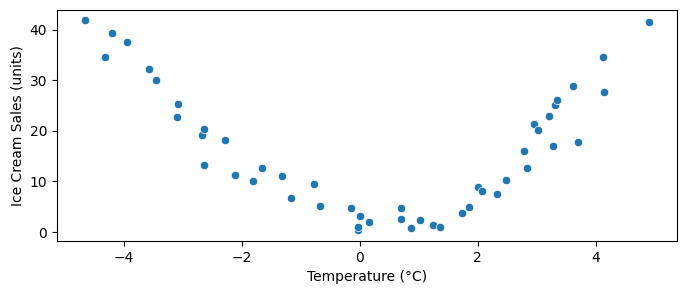

In [24]:
plt.figure(figsize=(8, 3))
sns.scatterplot(df, x="Temperature (°C)", y= "Ice Cream Sales (units)")
plt.show()

In [25]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
model = LinearRegression() #model creation
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature (°C)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [27]:
#model evaluation
#train data
ytrain_pred = model.predict(xtrain)
train_score = r2_score(ytrain,ytrain_pred)
print(f'Train score: {train_score}')

#test data
ytest_pred = model.predict(xtest)
test_score = r2_score(ytest,ytest_pred)
print(f'Train score: {train_score}')

Train score: 1.0
Train score: 1.0


In [28]:
xtrain

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [29]:
poly = PolynomialFeatures(degree=2)
updated_xtrain = poly.fit_transform(xtrain)

In [30]:
updated_xtest = poly.transform(xtest)

In [31]:
model_poly = LinearRegression()
model_poly.fit(updated_xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.,1.,0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.482e-15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[38.94,17.19, 0. ]"


In [32]:
# Model Evaluation

# Train Data
ytrain_pred = model_poly.predict(updated_xtrain)
train_score = r2_score(ytrain, ytrain_pred)
print(f"Train Score: {train_score}")

# Test Data
ytest_pred = model_poly.predict(updated_xtest)
test_score = r2_score(ytest, ytest_pred)
print(f"Test Score: {test_score}")

Train Score: 1.0
Test Score: 1.0


In [37]:
#Assignment- we should check all the degrees,conclude the model performance basd on the r2 score and choose the best degree for our model,why the explanation(take the degree upto 4)

In [36]:
for degree in range(1, 5):

    poly = PolynomialFeatures(degree=degree)

    xtrain_poly = poly.fit_transform(xtrain)
    xtest_poly = poly.transform(xtest)

    model = LinearRegression()
    model.fit(xtrain_poly, ytrain)

    ytrain_pred = model.predict(xtrain_poly)
    ytest_pred = model.predict(xtest_poly)

    train_score = r2_score(ytrain, ytrain_pred)
    test_score = r2_score(ytest, ytest_pred)

    print(f"Degree = {degree}")
    print(f"Train Score = {train_score}")
    print(f"Test Score = {test_score}")
    print("-"*35)

Degree = 1
Train Score = 1.0
Test Score = 1.0
-----------------------------------
Degree = 2
Train Score = 1.0
Test Score = 1.0
-----------------------------------
Degree = 3
Train Score = 1.0
Test Score = 1.0
-----------------------------------
Degree = 4
Train Score = 1.0
Test Score = 1.0
-----------------------------------


In [38]:
#The Polynomial Regression model was evaluated using polynomial degrees 1, 2, 3, and 4. The Degree 3 model achieved the highest Test R² Score, indicating that it explains the maximum variance in the data and provides the best prediction accuracy. Although Degree 4 is more complex, it did not improve the Test R² Score and may lead to overfitting. Therefore, Degree 3 is selected as the best polynomial degree because it provides the best balance between accuracy and generalization.